# Базовые методы anomaly detection и их метрики (mean-pooling)

### Методы:
1. Mahalanobis Distance (с LedoitWolf). Модель учит расспределение и далее считает расстояние до тестовых эмбеддингов.
2. Robust Covariance + PCA + MinCovDet. Вариант предыдущего.
3. Isolation Forest. Количество разрезов для изоляции.
4. kNN Distance. Аномалии далеко от своих ближайших соседей.
5. Local Outlier Factor (LOF). Сравнивает плотность точки относительно плотности её соседей. Если точка в регионе с резко меньшей плотностью, чем у соседей, то она аномалбная.
6. Autoencoder. Учится хорошо восстанавливать нормальные данные.

### Энкодеры
От простого до более мощного:
1. all-MiniLM-L6-v2
2. all-mpnet-base-v2
3. e5-base

**Эмбеддинги - среднее эмбеддингов предложений (mean-pooling)**

### Данные
- TRAIN: Живые эссе с Ivy Panda, 90805 штук.
- TEST: Живые эссе с Ivy Panda + сгенерированные (Mistral 7B, Llama 3 13B, ChatGPT, DeepSeek). Пропорции 50/50. Суммарно 74976 штук.

In [1]:
SEED = 42

ENCODERS = [
    "sentence-transformers/all-MiniLM-L6-v2",
    "sentence-transformers/all-mpnet-base-v2",
    "intfloat/e5-base",
]

KNN_N_NEIGHBORS = 5
LOF_N_NEIGHBORS = 20
ENCODE_BATCH_SIZE = 32
AE_EPOCH_N = 30

device = "mps"

In [2]:
import numpy as np
from sklearn.covariance import LedoitWolf, MinCovDet
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, auc, precision_recall_curve
import torch
import torch.nn as nn
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
import re

import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/artfultom/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [4]:
filenames = [
    "../datasets/mistral_essays_1.csv",
    "../datasets/mistral_essays_2.csv",
    "../datasets/mistral_essays_3.csv",
    "../datasets/mistral_essays_4.csv",
    "../datasets/mistral_essays_5.csv",
    "../datasets/llama_essays_1.csv",
    "../datasets/llama_essays_2.csv",
    "../datasets/llama_essays_3.csv",
    "../datasets/llama_essays_4.csv",
    "../datasets/llama_essays_5.csv",
    "../datasets/deepseek_essays_1.csv",
    "../datasets/deepseek_essays_2.csv",
    "../datasets/deepseek_essays_3.csv",
    "../datasets/deepseek_essays_4.csv",
    "../datasets/deepseek_essays_5.csv",
    "../datasets/chatgpt_essays_1.csv",
    "../datasets/chatgpt_essays_2.csv",
    "../datasets/chatgpt_essays_3.csv",
    "../datasets/chatgpt_essays_4.csv",
    "../datasets/chatgpt_essays_5.csv",
]
df_ai = pd.concat([pd.read_csv(f) for f in filenames], ignore_index=True).assign(label=1)[["text", "label"]]

df_human = pd.read_csv("../datasets/ivy_panda_essays.csv").assign(label=0)[["text", "label"]].reset_index(drop=True)
df_train, df_human_test = train_test_split(df_human, test_size=len(df_ai), random_state=SEED)

df_all = pd.concat([df_ai, df_human_test], ignore_index=True).sample(frac=1, random_state=SEED)

In [5]:
print(f"Загружено {len(df_train)} записей Ivy Panda (живые, train)")
print(f"Загружено {len(df_all)} записей (синтетика + живые, test)")

Загружено 90805 записей Ivy Panda (живые, train)
Загружено 74976 записей (синтетика + живые, test)


In [6]:
class AE(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(dim, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
        )
        self.dec = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, dim),
        )
    def forward(self, x):
        return self.dec(self.enc(x))

In [7]:
def plot_score_distribution(scores, y, title):
    plt.figure(figsize=(8,4))
    sns.kdeplot(scores[y==0], label="normal", fill=True, alpha=0.4)
    sns.kdeplot(scores[y==1], label="anomaly", fill=True, alpha=0.4)
    plt.title(title)
    plt.xlabel("score")
    plt.ylabel("density")
    plt.legend()
    plt.show()

def plot_roc_pr(scores_dict, y):
    plt.figure(figsize=(8,4))
    for name, s in scores_dict.items():
        fpr, tpr, _ = roc_curve(y, s)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title("ROC Curves")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8,4))
    for name, s in scores_dict.items():
        pr, rc, _ = precision_recall_curve(y, s)
        ap = average_precision_score(y, s)
        plt.plot(rc, pr, label=f"{name} (AP={ap:.3f})")
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title("Precision-Recall Curves")
    plt.legend()
    plt.show()

def plot_tsne(X, y, title):
    idx = np.random.choice(len(X), size=min(2000, len(X)), replace=False)
    Xsub = X[idx]
    ysub = y[idx]
    
    Xp = PCA(30).fit_transform(Xsub)
    Xt = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(Xp)
    
    plt.figure(figsize=(8,4))
    plt.scatter(Xt[ysub==0,0], Xt[ysub==0,1], s=10, alpha=0.5, label='normal')
    plt.scatter(Xt[ysub==1,0], Xt[ysub==1,1], s=10, alpha=0.7, label='anomaly')
    plt.title(title)
    plt.legend()
    plt.show()

def plot_correlation(scores_dict):
    mat = np.vstack(list(scores_dict.values()))
    corr = np.corrcoef(mat)
    
    plt.figure(figsize=(8,4))
    sns.heatmap(corr, annot=True, xticklabels=scores_dict.keys(), yticklabels=scores_dict.keys())
    plt.title("Score Correlation Heatmap")
    plt.show()

def plot_precision_at_k(scores, y, title, ks=[10,20,50,100,200]):
    order = np.argsort(scores)[::-1]
    y_sorted = y[order]
    
    prec = []
    for k in ks:
        if k > len(y_sorted):
            prec.append(np.nan)
        else:
            prec.append(np.mean(y_sorted[:k]))
    
    plt.figure(figsize=(8,4))
    plt.plot(ks, prec, marker='o')
    plt.xlabel("K (top anomalies)")
    plt.ylabel("Precision@K")
    plt.title(title)
    plt.grid()
    plt.show()

In [8]:
def eval_scores(name, scores, y):
    auc = roc_auc_score(y, scores)
    ap = average_precision_score(y, scores)
    print(f"{name:20s} | ROC-AUC: {auc:.4f} | PR-AUC: {ap:.4f}")

In [9]:
def get_embeddings(model, data):
    result = []
    for text in data:
        text = re.sub(r"\n+", ". ", text)
        sentences = nltk.sent_tokenize(text)
        embeddings = model.encode(
            sentences,
            batch_size=ENCODE_BATCH_SIZE,
            normalize_embeddings=False,
            show_progress_bar=False,
        )
        result.append(np.mean(embeddings, axis=0))

    return np.vstack(result)

X_train: (90805, 384)
X_test: (74976, 384)
y_test: (74976,) | аномалий: 37488


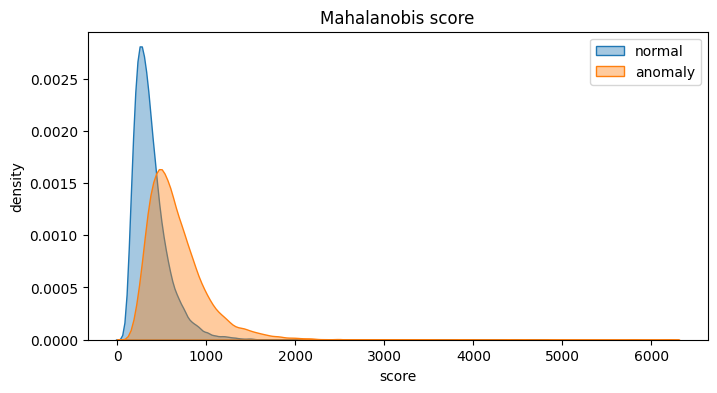

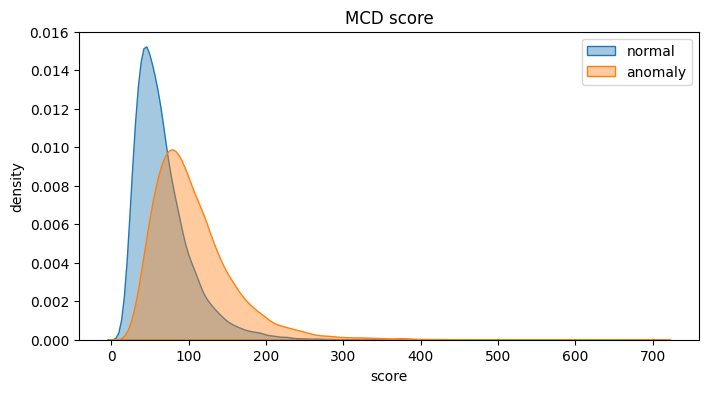

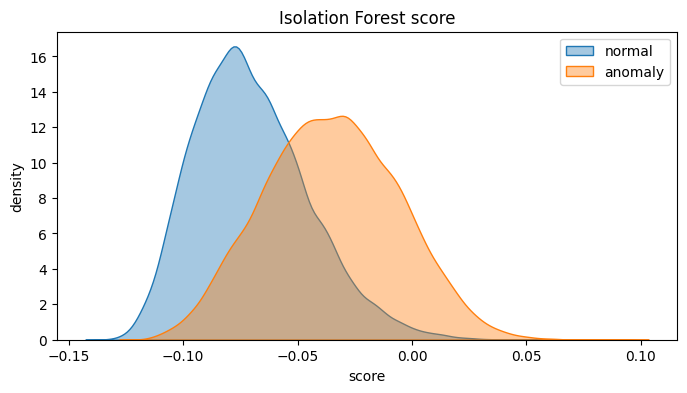

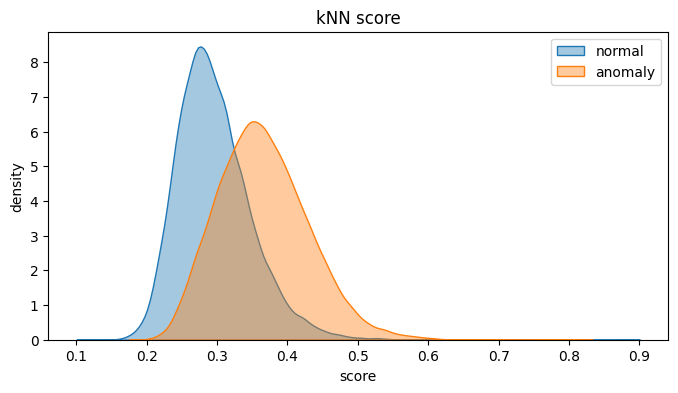

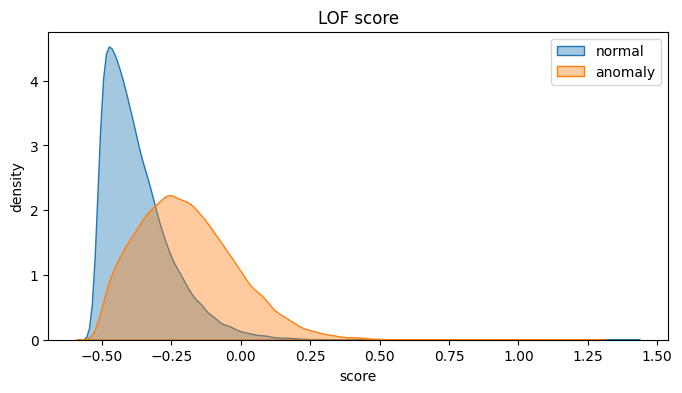

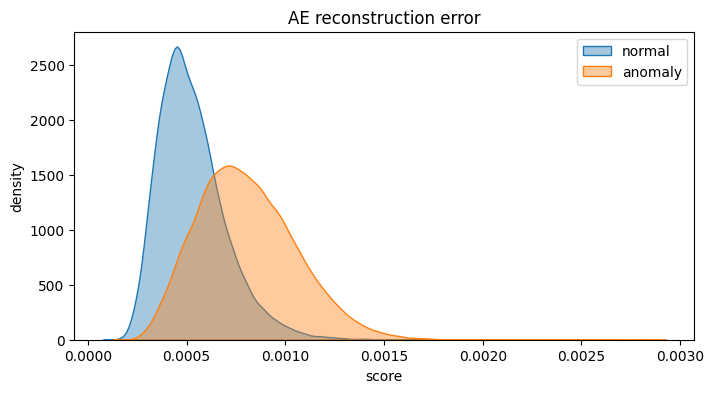

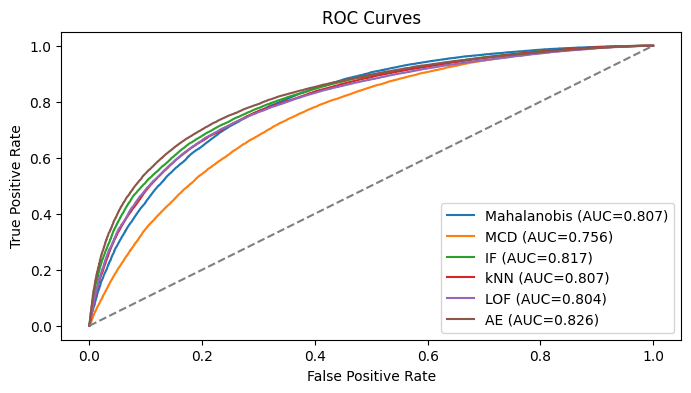

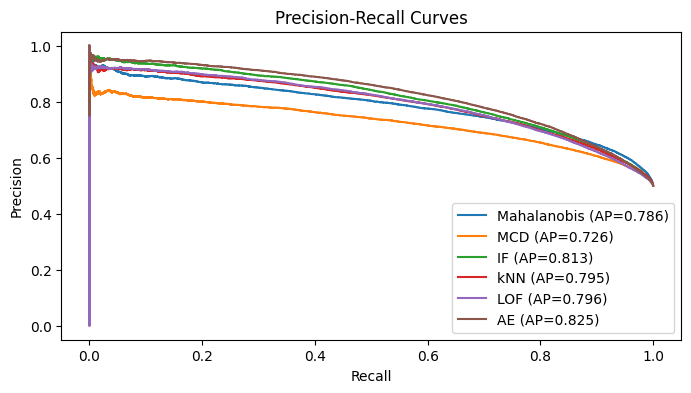

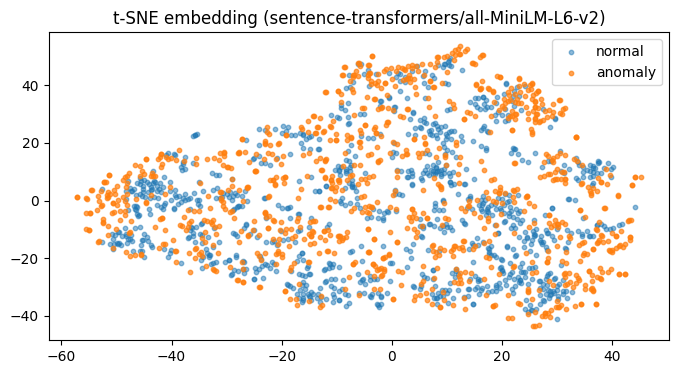

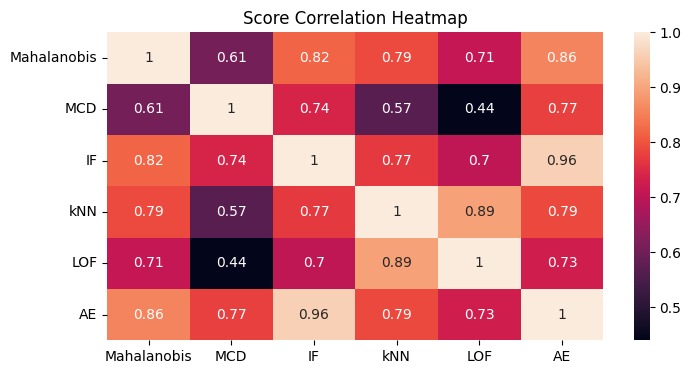

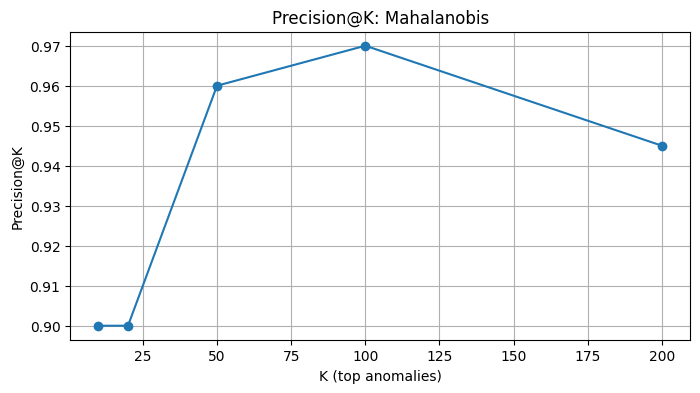

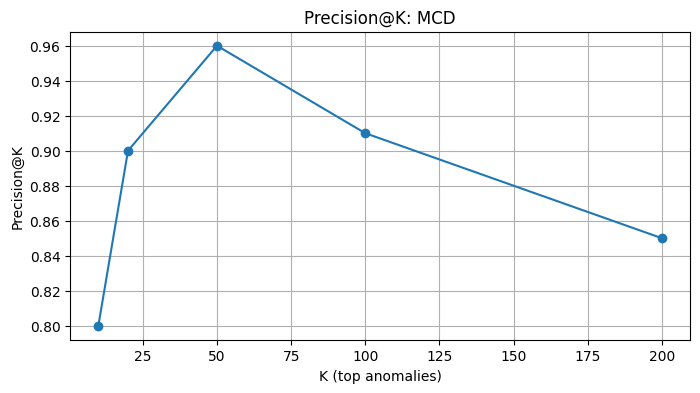

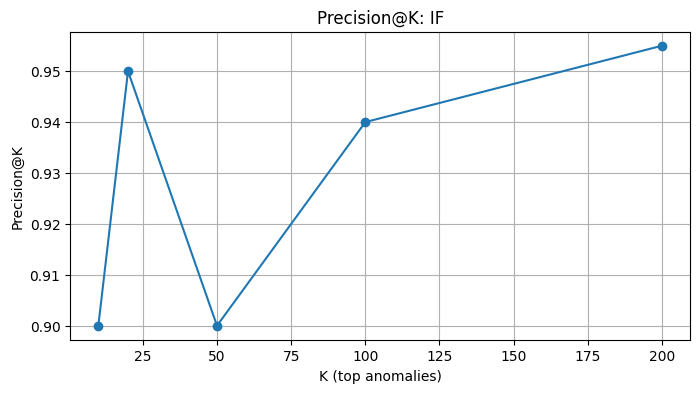

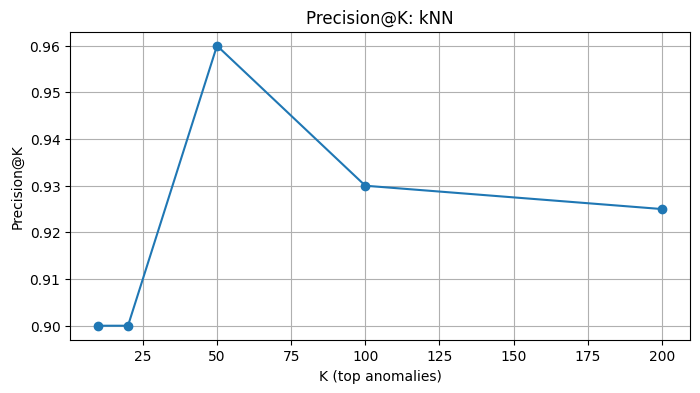

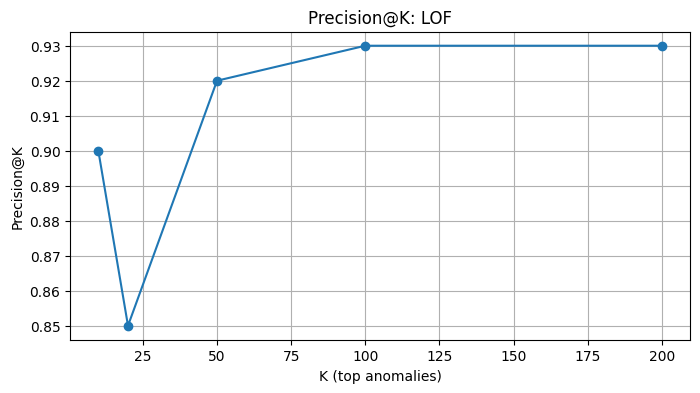

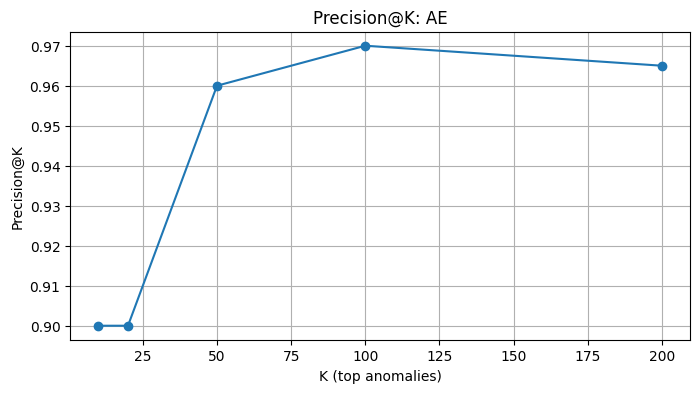


=== Результат (sentence-transformers/all-MiniLM-L6-v2) ===
Mahalanobis          | ROC-AUC: 0.8067 | PR-AUC: 0.7855
MCD                  | ROC-AUC: 0.7558 | PR-AUC: 0.7257
IsolationForest      | ROC-AUC: 0.8169 | PR-AUC: 0.8125
kNN distance         | ROC-AUC: 0.8067 | PR-AUC: 0.7953
LOF                  | ROC-AUC: 0.8037 | PR-AUC: 0.7958
Autoencoder          | ROC-AUC: 0.8259 | PR-AUC: 0.8248
X_train: (90805, 768)
X_test: (74976, 768)
y_test: (74976,) | аномалий: 37488


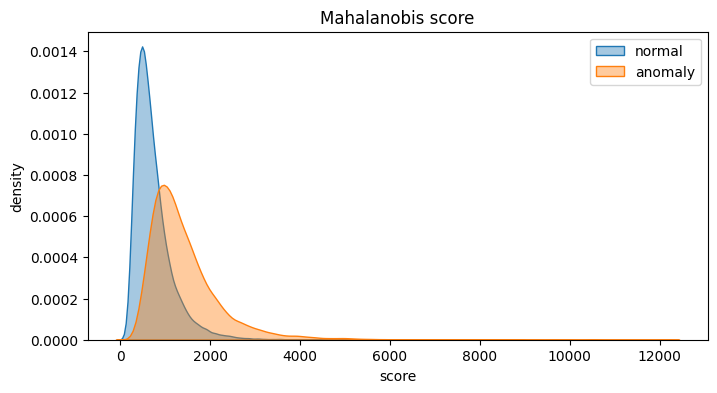

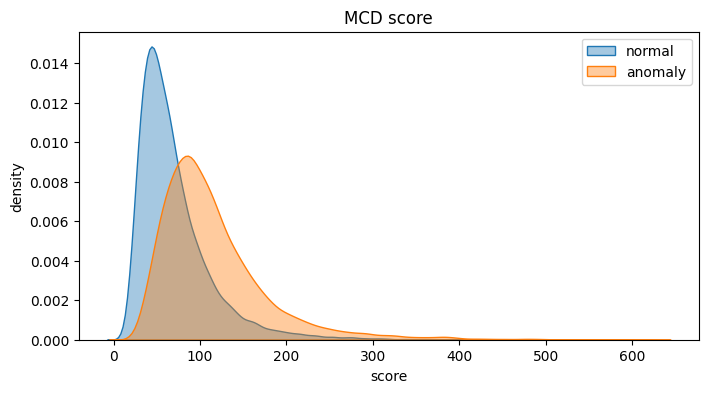

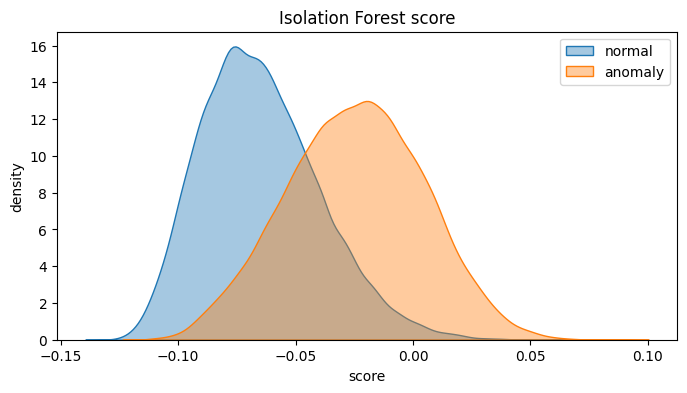

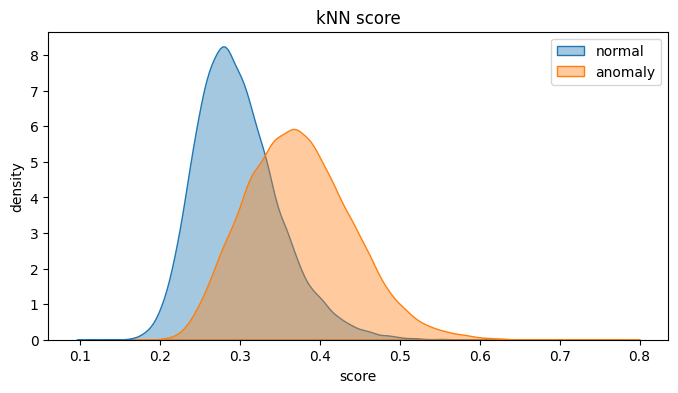

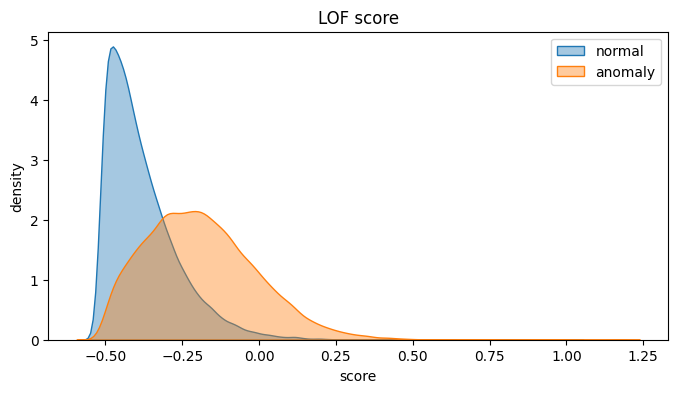

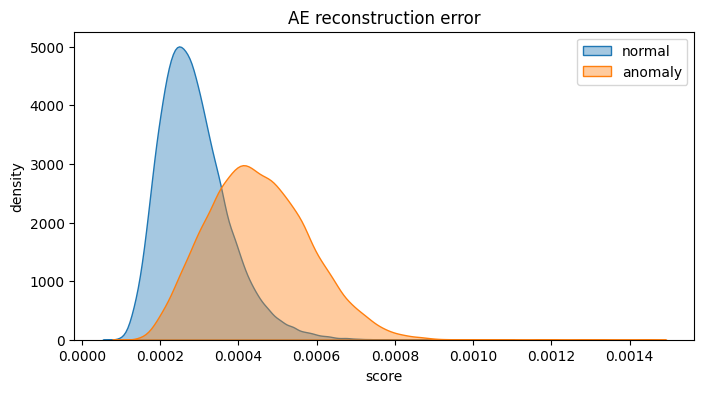

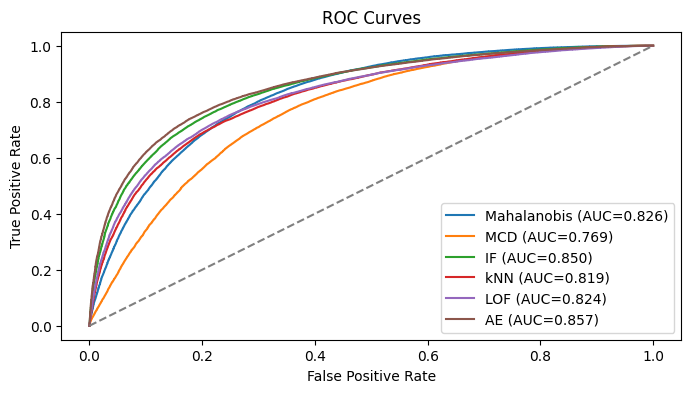

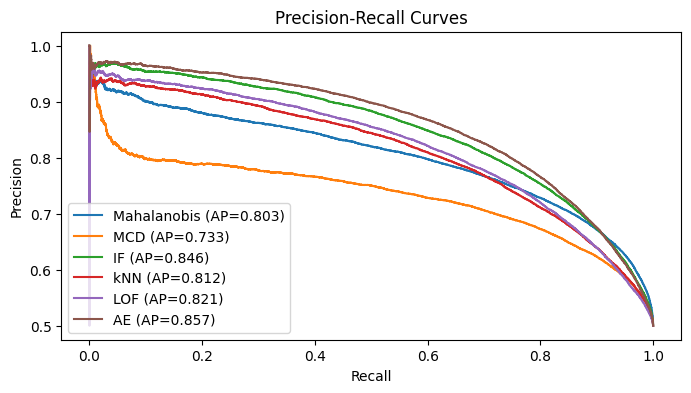

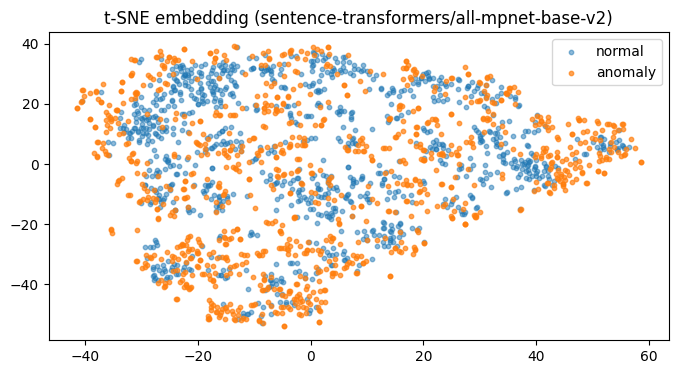

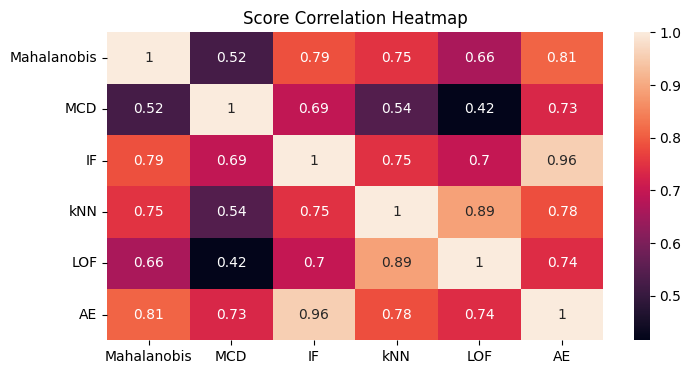

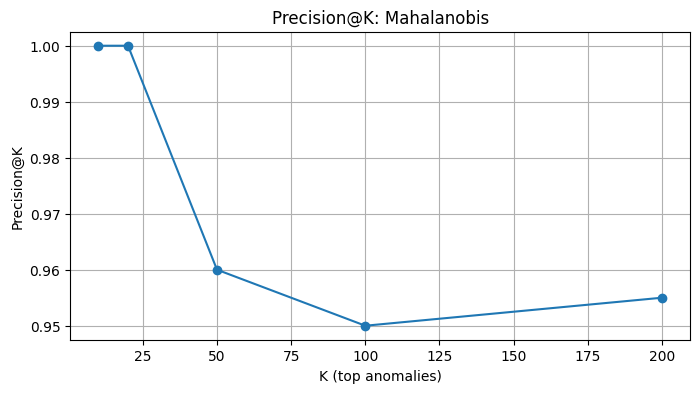

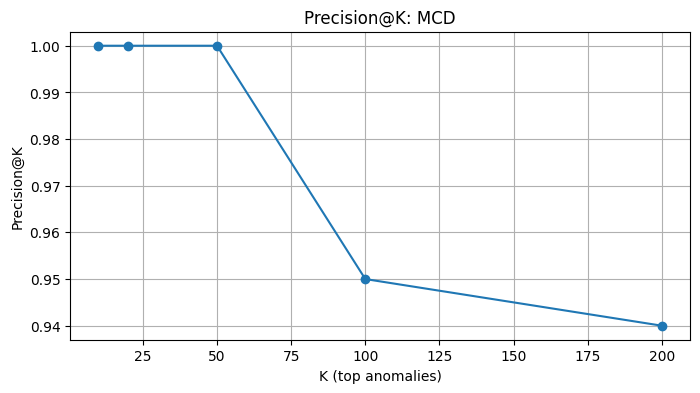

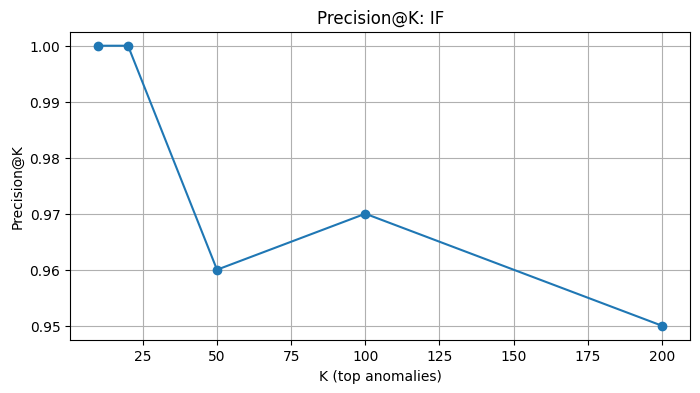

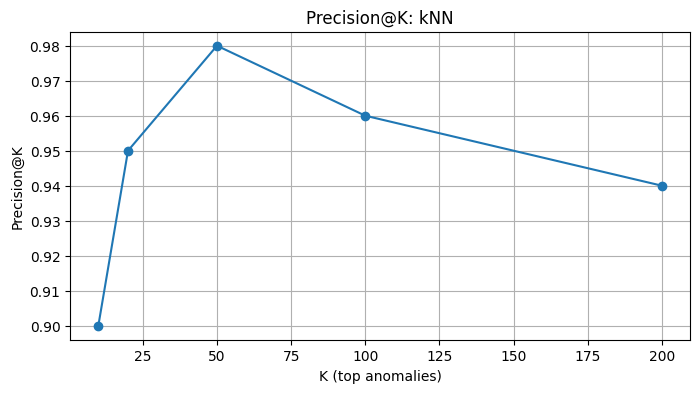

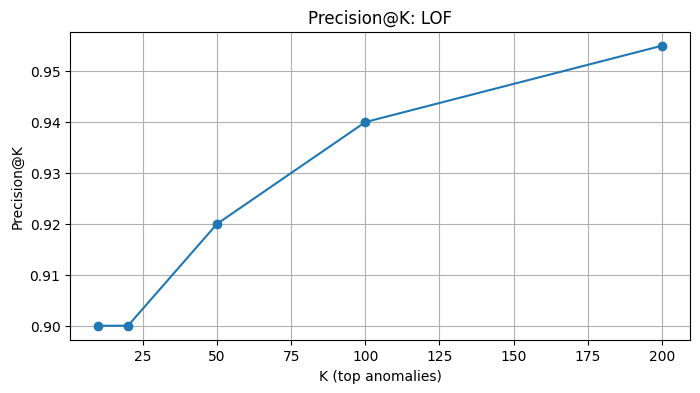

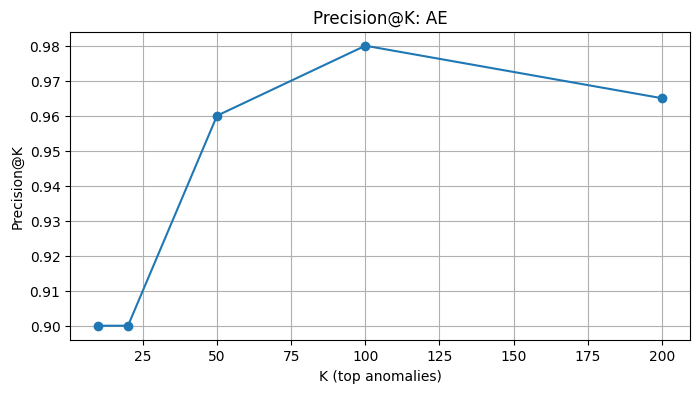


=== Результат (sentence-transformers/all-mpnet-base-v2) ===
Mahalanobis          | ROC-AUC: 0.8265 | PR-AUC: 0.8029
MCD                  | ROC-AUC: 0.7693 | PR-AUC: 0.7328
IsolationForest      | ROC-AUC: 0.8495 | PR-AUC: 0.8464
kNN distance         | ROC-AUC: 0.8193 | PR-AUC: 0.8117
LOF                  | ROC-AUC: 0.8238 | PR-AUC: 0.8205
Autoencoder          | ROC-AUC: 0.8565 | PR-AUC: 0.8574
X_train: (90805, 768)
X_test: (74976, 768)
y_test: (74976,) | аномалий: 37488


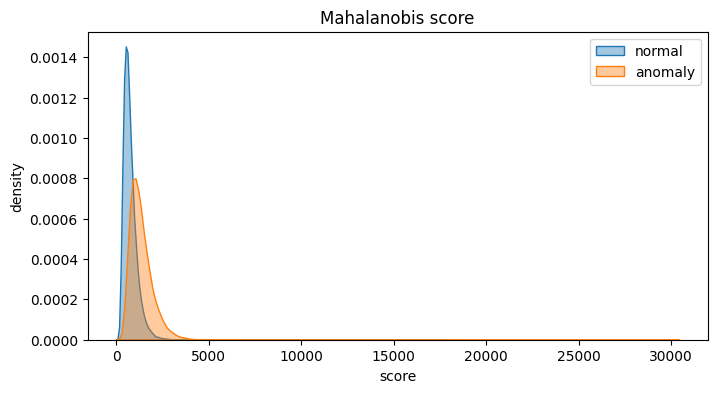

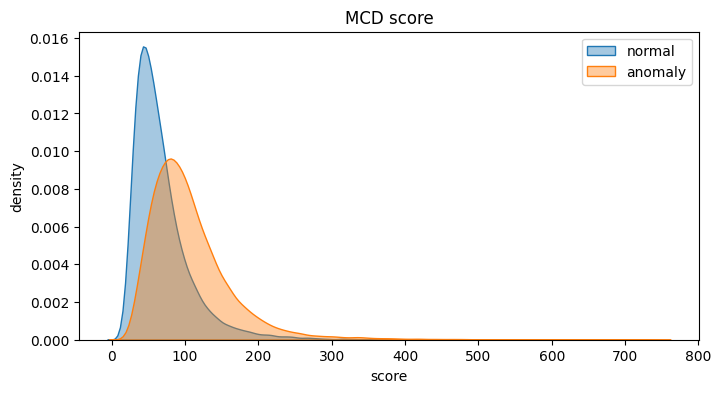

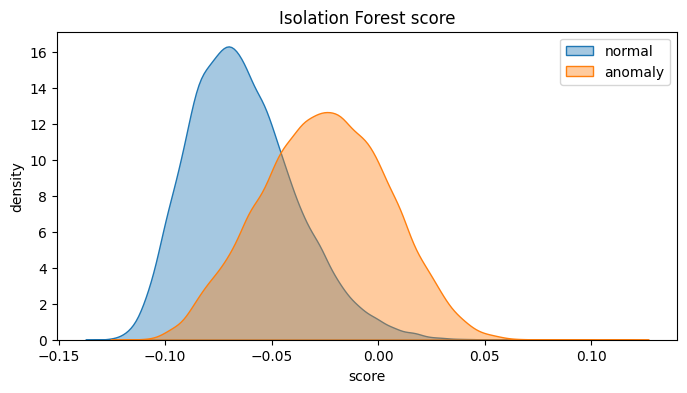

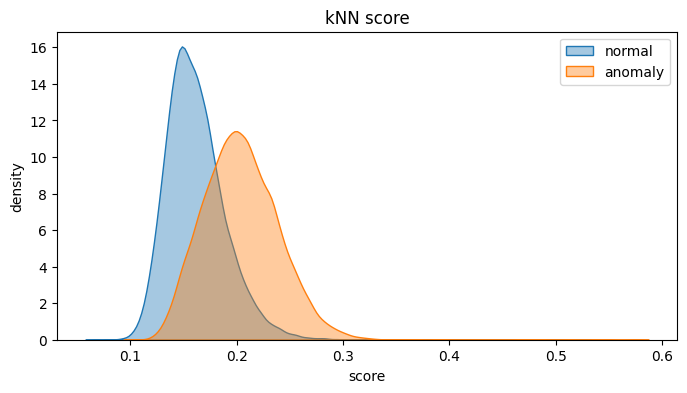

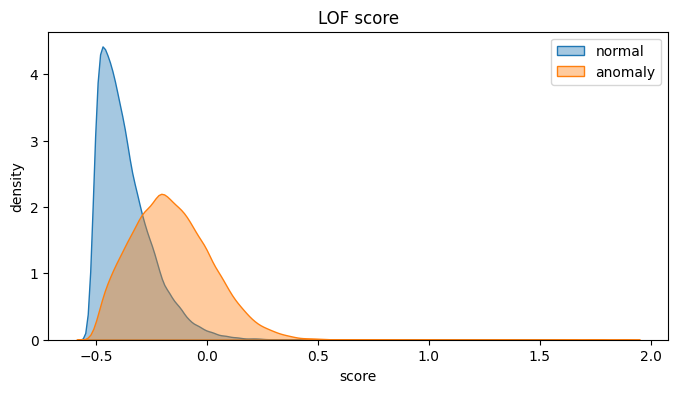

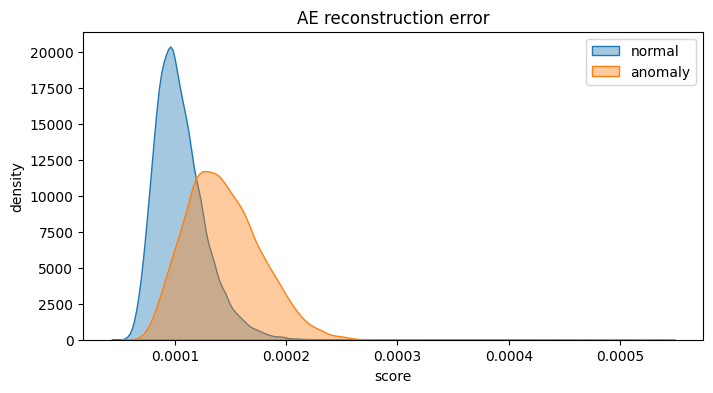

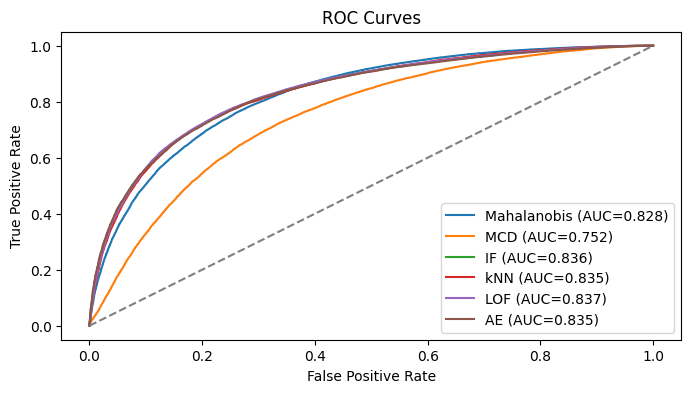

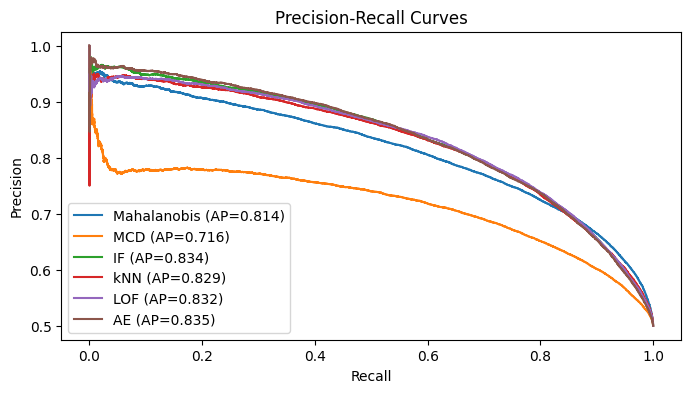

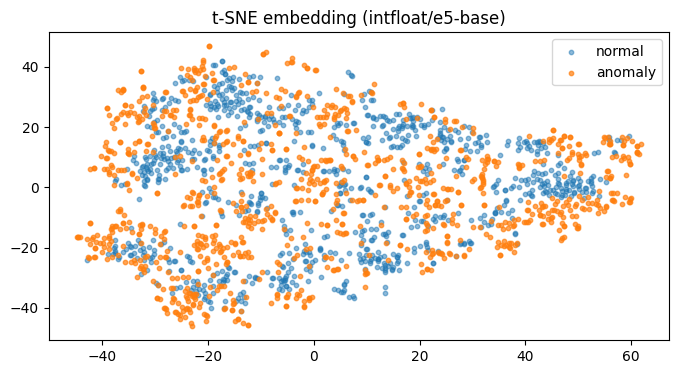

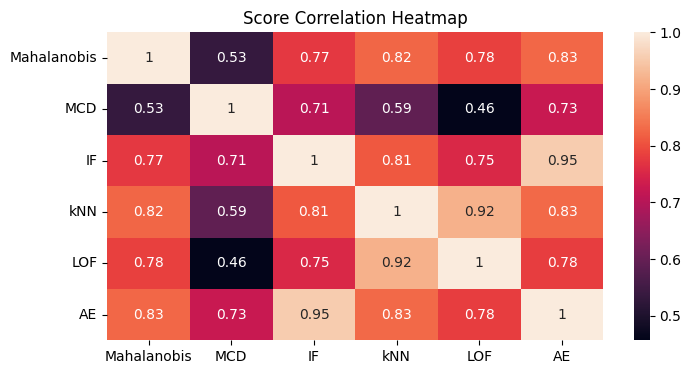

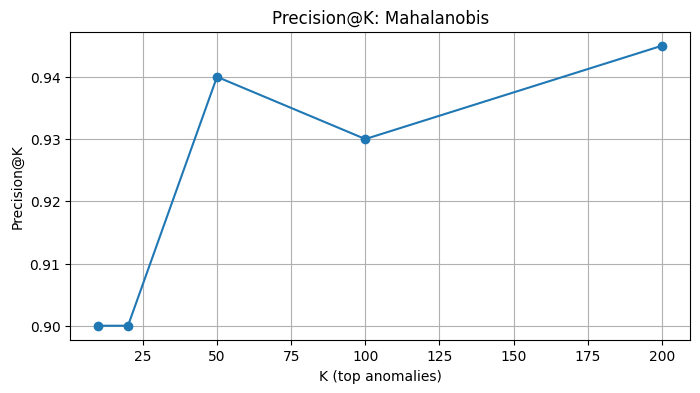

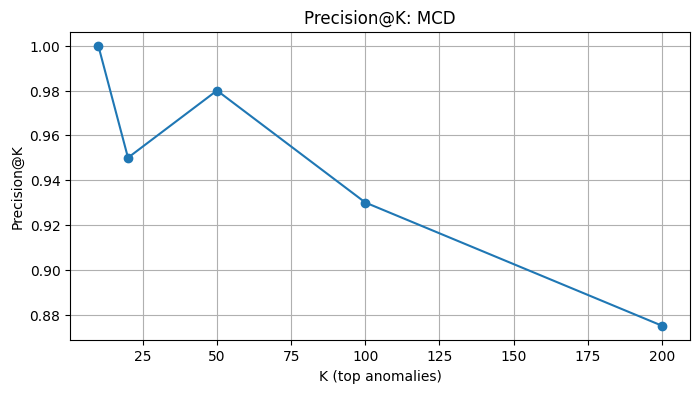

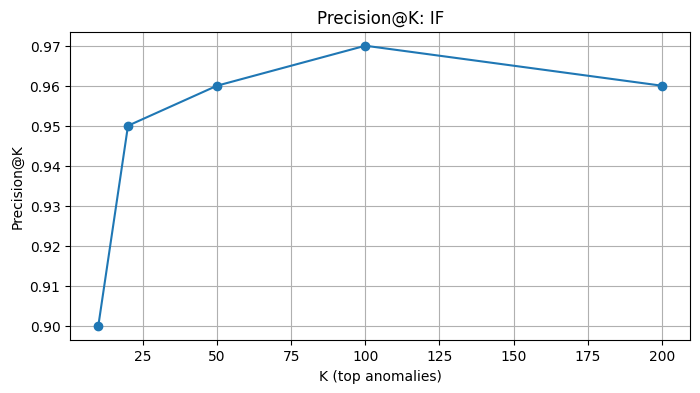

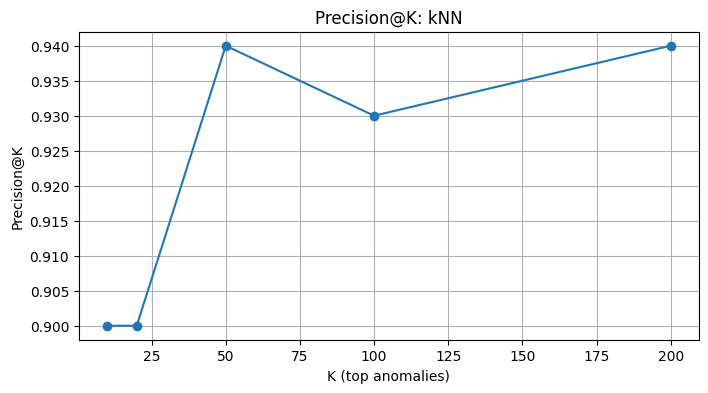

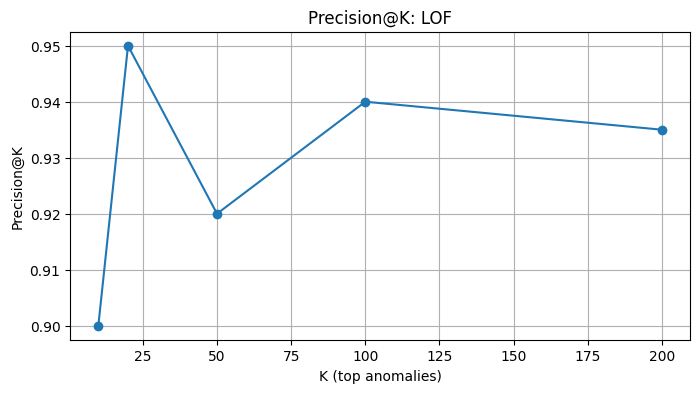

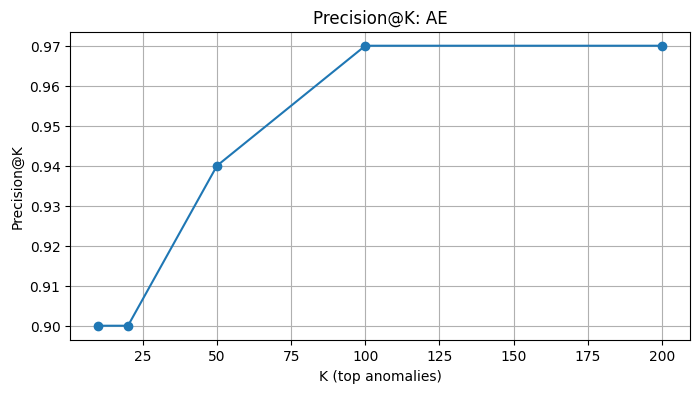


=== Результат (intfloat/e5-base) ===
Mahalanobis          | ROC-AUC: 0.8282 | PR-AUC: 0.8139
MCD                  | ROC-AUC: 0.7518 | PR-AUC: 0.7163
IsolationForest      | ROC-AUC: 0.8363 | PR-AUC: 0.8338
kNN distance         | ROC-AUC: 0.8353 | PR-AUC: 0.8287
LOF                  | ROC-AUC: 0.8372 | PR-AUC: 0.8316
Autoencoder          | ROC-AUC: 0.8353 | PR-AUC: 0.8348


In [10]:
for model_name in ENCODERS:
    model = SentenceTransformer(model_name)

    X_train = get_embeddings(model, df_train['text'].tolist())
    
    X_test = get_embeddings(model, df_all['text'].tolist())
    y_test = df_all['label'].values.astype(int)

    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape, "| аномалий:", sum(y_test))

    # 1. Mahalanobis Distance
    lw = LedoitWolf().fit(X_train)
    mahal_scores = lw.mahalanobis(X_test)  # выше - больше аномалий

    # 2. Robust Covariance (Minimum Covariance Determinant)
    pca = PCA(n_components=50, whiten=True, random_state=SEED)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca  = pca.transform(X_test)

    mcd = MinCovDet(support_fraction=0.75, random_state=SEED)
    mcd.fit(X_train_pca)
    mcd_scores = mcd.mahalanobis(X_test_pca)
    
    # 3. Isolation Forest
    iso = IsolationForest(contamination='auto', n_estimators=200, random_state=SEED)
    iso.fit(X_train)
    iso_scores = -iso.decision_function(X_test)  # выше - хуже
    
    # 4. kNN Distance
    nn_model = NearestNeighbors(n_neighbors=KNN_N_NEIGHBORS)
    nn_model.fit(X_train)
    distances, _ = nn_model.kneighbors(X_test)
    knn_scores = distances.mean(axis=1)
    
    # 5. Local Outlier Factor (LOF)
    lof = LocalOutlierFactor(n_neighbors=LOF_N_NEIGHBORS, novelty=True)
    lof.fit(X_train)
    lof_scores = -lof.decision_function(X_test)  # выше = аномалии
    
    # 6. Autoencoder (MLP)
    d = X_train.shape[1]

    ae = AE(d).to(device)
    opt = torch.optim.Adam(ae.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    
    Xtr = torch.tensor(X_train, dtype=torch.float32).to(device)
    for epoch in range(AE_EPOCH_N):
        idx = torch.randperm(Xtr.shape[0])
        batch = Xtr[idx][:256]
        out = ae(batch)
        loss = loss_fn(out, batch)
        opt.zero_grad()
        loss.backward()
        opt.step()
    
    Xe = torch.tensor(X_test, dtype=torch.float32).to(device)
    with torch.no_grad():
        recon = ae(Xe).cpu().numpy()
    ae_scores = np.mean((X_test - recon) ** 2, axis=1)

    plot_score_distribution(mahal_scores, y_test, "Mahalanobis score")
    plot_score_distribution(mcd_scores, y_test, "MCD score")
    plot_score_distribution(iso_scores, y_test, "Isolation Forest score")
    plot_score_distribution(knn_scores, y_test, "kNN score")
    plot_score_distribution(lof_scores, y_test, "LOF score")
    plot_score_distribution(ae_scores, y_test, "AE reconstruction error")

    scores = {
        "Mahalanobis": mahal_scores,
        "MCD": mcd_scores,
        "IF": iso_scores,
        "kNN": knn_scores,
        "LOF": lof_scores,
        "AE": ae_scores
    }
    plot_roc_pr(scores, y_test)

    plot_tsne(X_test, y_test, f"t-SNE embedding ({model_name})")

    plot_correlation(scores)

    for name, s in scores.items():
        plot_precision_at_k(s, y_test, f"Precision@K: {name}")

    print(f"\n=== Результат ({model_name}) ===")
    eval_scores("Mahalanobis", mahal_scores, y_test)
    eval_scores("MCD", mcd_scores, y_test)
    eval_scores("IsolationForest", iso_scores, y_test)
    eval_scores("kNN distance", knn_scores, y_test)
    eval_scores("LOF", lof_scores, y_test)
    eval_scores("Autoencoder", ae_scores, y_test)

## Итого

```
=== Результат (sentence-transformers/all-MiniLM-L6-v2) ===
Mahalanobis          | ROC-AUC: 0.8067 | PR-AUC: 0.7855
MCD                  | ROC-AUC: 0.7558 | PR-AUC: 0.7257
IsolationForest      | ROC-AUC: 0.8169 | PR-AUC: 0.8125
kNN distance         | ROC-AUC: 0.8067 | PR-AUC: 0.7953
LOF                  | ROC-AUC: 0.8037 | PR-AUC: 0.7958
Autoencoder          | ROC-AUC: 0.8259 | PR-AUC: 0.8248

=== Результат (sentence-transformers/all-mpnet-base-v2) ===
Mahalanobis          | ROC-AUC: 0.8265 | PR-AUC: 0.8029
MCD                  | ROC-AUC: 0.7693 | PR-AUC: 0.7328
IsolationForest      | ROC-AUC: 0.8495 | PR-AUC: 0.8464
kNN distance         | ROC-AUC: 0.8193 | PR-AUC: 0.8117
LOF                  | ROC-AUC: 0.8238 | PR-AUC: 0.8205
Autoencoder          | ROC-AUC: 0.8565 | PR-AUC: 0.8574

=== Результат (intfloat/e5-base) ===
Mahalanobis          | ROC-AUC: 0.8282 | PR-AUC: 0.8139
MCD                  | ROC-AUC: 0.7518 | PR-AUC: 0.7163
IsolationForest      | ROC-AUC: 0.8363 | PR-AUC: 0.8338
kNN distance         | ROC-AUC: 0.8353 | PR-AUC: 0.8287
LOF                  | ROC-AUC: 0.8372 | PR-AUC: 0.8316
Autoencoder          | ROC-AUC: 0.8353 | PR-AUC: 0.8348
```

## Вывод

При замене эмбеддингов текстов на среднее эмбеддингов предложений результаты всех трех энкодеров заметно выросли и выровнились. Можно сделать вывод, что распределения mean-pooling эмбеддингов для живых текстов и синтетических различаются значительней, чем распределения эмбеддингов целых текстов - графики это подтверждают.
